In [1]:
import pandas as pd
import numpy as np

# Load Crop Production Dataset
crop_df = pd.read_csv(r"C:\Users\Admin\Desktop\ML_Lab\crop_production.csv")

# Load City Day Dataset
city_df = pd.read_csv(r"C:\Users\Admin\Desktop\ML_Lab\city_day.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [2]:
print("Crop Production Dataset")
display(crop_df.head())

print("\nCity Day Dataset")
display(city_df.head())

Crop Production Dataset


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0



City Day Dataset


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
def dataset_profile(df, name):
    print("="*60)
    print(f"DATASET: {name}")
    print("="*60)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

dataset_profile(crop_df, "Crop Production")
dataset_profile(city_df, "City Day")

DATASET: Crop Production

Shape:
(246091, 7)

Columns:
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']

Data Types:
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object

Missing Values:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64
DATASET: City Day

Shape:
(29531, 16)

Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data Types:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       fl

In [4]:
print("Crop Production Dataset Info")
crop_df.info()

print("\n\nCity Day Dataset Info")
city_df.info()

Crop Production Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


City Day Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO       

# Task 1: Dataset Inspection

I loaded and inspected both datasets to understand their structure before starting any analysis.

### Crop Production Dataset

* Total records: 246091
* Total columns: 7
* Contains information about states, districts, crop year, season, crop type, area, and production.
* Production column contains some missing values.
* No duplicate records were found.

### City Day Dataset

* Total records: 29531
* Total columns: 16
* Contains daily air quality measurements for different cities.
* Several columns such as PM2.5, PM10, NH3, AQI, and AQI_Bucket contain missing values.
* No duplicate records were found.

### Observation

Before building any machine learning model, the missing values need to be handled properly. The City Day dataset requires more cleaning because multiple columns contain null values.


In [5]:
print("Crop Dataset Duplicate Rows:", crop_df.duplicated().sum())
print("City Dataset Duplicate Rows:", city_df.duplicated().sum())

Crop Dataset Duplicate Rows: 0
City Dataset Duplicate Rows: 0


In [6]:
print("Crop Dataset Statistics")
display(crop_df.describe())

print("\nCity Dataset Statistics")
display(city_df.describe())

Crop Dataset Statistics


,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09



City Dataset Statistics


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [7]:
print("Crop Dataset Categorical Summary")
display(crop_df.describe(include='object'))

print("\nCity Dataset Categorical Summary")
display(city_df.describe(include='object'))

Crop Dataset Categorical Summary


,State_Name,District_Name,Season,Crop
count,246091,246091,246091,246091
unique,33,646,6,124
top,Uttar Pradesh,BIJAPUR,Kharif,Rice
freq,33306,945,95951,15104



City Dataset Categorical Summary


,City,Date,AQI_Bucket
count,29531,29531,24850
unique,26,2009,6
top,Ahmedabad,2020-06-26,Moderate
freq,2009,26,8829


In [8]:
print("Crop Dataset Missing Values")
print(crop_df.isnull().sum())

print("\n" + "="*50 + "\n")

print("City Dataset Missing Values")
print(city_df.isnull().sum())

Crop Dataset Missing Values
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


City Dataset Missing Values
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [9]:
# Create copies
crop_clean = crop_df.copy()
city_clean = city_df.copy()

# Crop Dataset
crop_clean.dropna(subset=['Production'], inplace=True)

# City Dataset
num_cols = city_clean.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    city_clean[col] = city_clean[col].fillna(city_clean[col].median())

city_clean['AQI_Bucket'] = city_clean['AQI_Bucket'].fillna(
    city_clean['AQI_Bucket'].mode()[0]
)

In [10]:
print("Crop Dataset After Treatment")
print(crop_clean.isnull().sum())

print("\nCity Dataset After Treatment")
print(city_clean.isnull().sum())

Crop Dataset After Treatment
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64

City Dataset After Treatment
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64


# Task 2: Missing Value Treatment

After checking the datasets, I found missing values in both files.

### Crop Production Dataset

* Production column had 3730 missing values.
* Since this is a small percentage of the dataset, I removed those rows.

### City Day Dataset

* Numerical columns such as PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene, Xylene, and AQI contained missing values.
* I used median imputation because these columns contain outliers and median is less affected by extreme values.

### AQI_Bucket

* AQI_Bucket is a categorical column.
* I filled missing values using the most frequent category (mode).

### Result

After applying the treatment, all missing values were successfully removed from both datasets.


In [11]:
#Tas 3

In [12]:
crop_states = sorted(crop_clean['State_Name'].unique())

print("Number of States in Crop Dataset:", len(crop_states))
print(crop_states)

Number of States in Crop Dataset: 33
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [13]:
print("Columns in City Dataset:")
print(city_clean.columns.tolist())

print("\nUnique Cities:")
print(sorted(city_clean['City'].unique()))

Columns in City Dataset:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Unique Cities:
['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']


In [14]:
print("Crop Dataset Duplicate Rows:", crop_clean.duplicated().sum())
print("City Dataset Duplicate Rows:", city_clean.duplicated().sum())

Crop Dataset Duplicate Rows: 0
City Dataset Duplicate Rows: 0


In [15]:
# Record counts before cleaning
crop_before = len(crop_clean)
city_before = len(city_clean)

# Remove leading and trailing spaces
crop_clean['State_Name'] = crop_clean['State_Name'].str.strip()
city_clean['City'] = city_clean['City'].str.strip()

print("Name standardization completed.")

Name standardization completed.


In [16]:
# Remove duplicate records

crop_clean = crop_clean.drop_duplicates()
city_clean = city_clean.drop_duplicates()

crop_after = len(crop_clean)
city_after = len(city_clean)

print("Crop Dataset Records Before:", crop_before)
print("Crop Dataset Records After :", crop_after)

print("\nCity Dataset Records Before:", city_before)
print("City Dataset Records After :", city_after)

Crop Dataset Records Before: 242361
Crop Dataset Records After : 242361

City Dataset Records Before: 29531
City Dataset Records After : 29531


In [17]:
print(sorted(crop_clean['State_Name'].unique()))

['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


# Task 3: Data Consistency and Duplicate Removal

I checked both datasets for inconsistencies and duplicate records.

### Inconsistencies Found

* Jammu and Kashmir had an extra space at the end of the name.
* Telangana also had an extra space at the end.

### Fix Applied

I used the strip() function to remove leading and trailing spaces from state and city names.

### Duplicate Check

* Crop Dataset Duplicate Rows: 0
* City Dataset Duplicate Rows: 0

Since no duplicate records were found, no rows were removed.

### Result

The naming inconsistencies were corrected and both datasets are now cleaner and ready for further analysis.


In [18]:
#Task 4

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

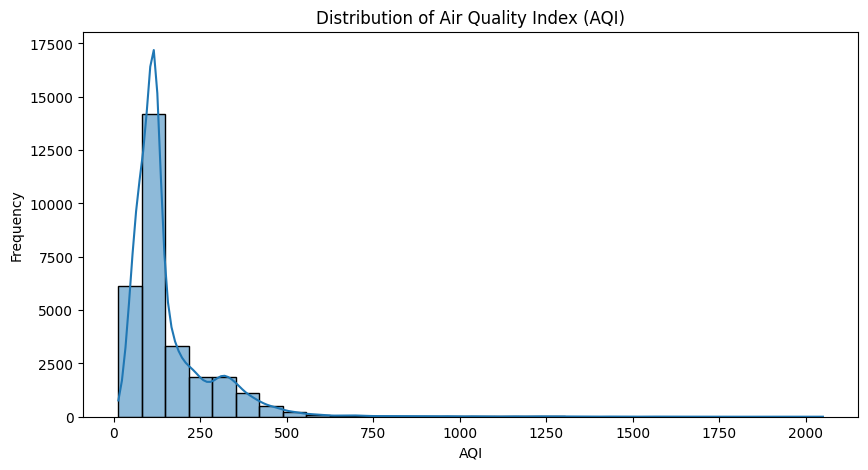

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(city_clean['AQI'], bins=30, kde=True)

plt.title('Distribution of Air Quality Index (AQI)')
plt.xlabel('AQI')
plt.ylabel('Frequency')

plt.show()

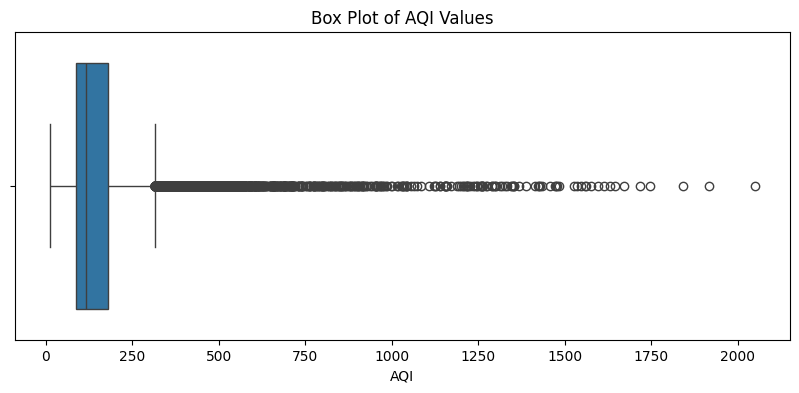

In [21]:
plt.figure(figsize=(10,4))

sns.boxplot(x=city_clean['AQI'])

plt.title('Box Plot of AQI Values')
plt.xlabel('AQI')

plt.show()

In [22]:
print("Mean AQI  :", city_clean['AQI'].mean())
print("Median AQI:", city_clean['AQI'].median())

Mean AQI  : 158.78155158985473
Median AQI: 118.0


# Task 4: AQI Distribution Analysis

To understand how AQI values are distributed, I used a histogram and a box plot.

### Why These Plots?

* The histogram shows where most AQI values are concentrated.
* The box plot helps identify extreme values and outliers.

### Observation 1

Most AQI values are concentrated in the lower AQI range, especially below 250. This suggests that extremely high pollution levels occur less frequently.

### Observation 2

The mean AQI (158.78) is higher than the median AQI (118). This indicates that some very high AQI values are increasing the average and making the pollution level appear worse than it is for most observations.

### Conclusion

The AQI distribution is positively skewed and contains several extreme values.


In [23]:
#Task 5

In [24]:
Q1 = city_clean['AQI'].quantile(0.25)
Q3 = city_clean['AQI'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = city_clean[
    (city_clean['AQI'] < lower_bound) |
    (city_clean['AQI'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

Q1: 88.0
Q3: 179.0
IQR: 91.0
Lower Bound: -48.5
Upper Bound: 315.5
Number of Outliers: 3192


In [25]:
city_outlier_treated = city_clean.copy()

city_outlier_treated['AQI'] = city_outlier_treated['AQI'].clip(
    lower=lower_bound,
    upper=upper_bound
)

print("Outlier treatment completed.")

Outlier treatment completed.


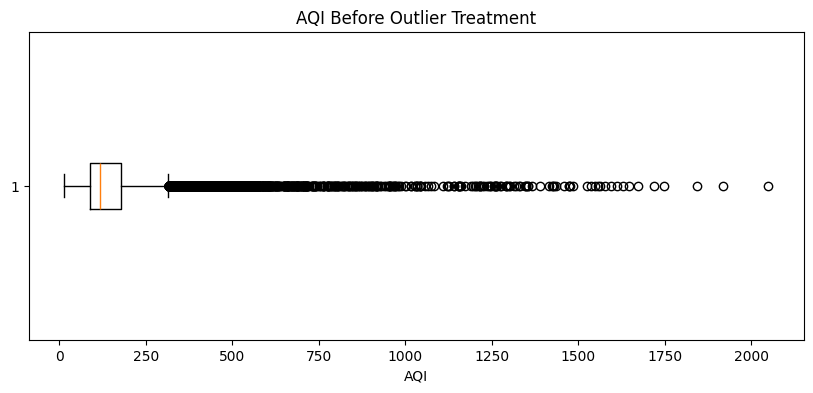

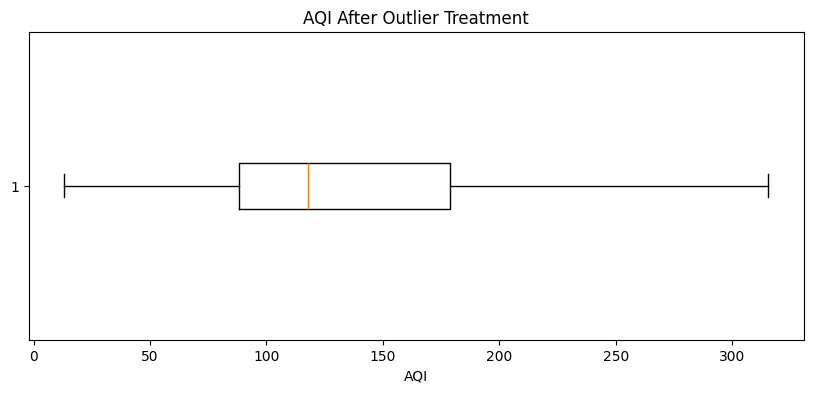

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.boxplot(city_clean['AQI'], vert=False)
plt.title('AQI Before Outlier Treatment')
plt.xlabel('AQI')
plt.show()

plt.figure(figsize=(10,4))
plt.boxplot(city_outlier_treated['AQI'], vert=False)
plt.title('AQI After Outlier Treatment')
plt.xlabel('AQI')
plt.show()

In [27]:
affected_count = (
    (city_clean['AQI'] < lower_bound) |
    (city_clean['AQI'] > upper_bound)
).sum()

print("Number of AQI values affected:", affected_count)

Number of AQI values affected: 3192


# Task 5: Outlier Detection and Treatment

The AQI data contained several extreme values that could affect statistical analysis and machine learning models.

### Method Used

I used the Interquartile Range (IQR) method to detect outliers.

### Calculations

* Q1 = 88
* Q3 = 179
* IQR = 91
* Lower Bound = -48.5
* Upper Bound = 315.5

### Outliers Found

A total of 3192 AQI values were identified as outliers.

### Treatment Applied

Instead of removing the records, I used capping (Winsorization). Values above the upper bound were replaced with the upper bound value.

### Result

The box plot after treatment shows that extreme AQI values have been controlled. The dataset is now less influenced by unrealistic values and is more suitable for analysis.
